In [176]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPooling2D, Rescaling
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import load_img
from glob import glob

In [177]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [178]:
# Defining the path for train and test images
data_dir_train = pathlib.Path('/content/drive/My Drive/app/Skin cancer ISIC The International Skin Imaging Collaboration/Train')
data_dir_test = pathlib.Path('/content/drive/My Drive/app/Skin cancer ISIC The International Skin Imaging Collaboration/Test')

In [179]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(f'Train image count = {image_count_train}')
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(f'Test image count = {image_count_test}')

Train image count = 2239
Test image count = 118


**Load using keras.preprocessing**

Let's load these images off disk using the helpful image_dataset_from_directory utility.

**Create a dataset**

Define some parameters for the loader:

In [180]:
batch_size = 32
img_height = 180
img_width = 180
n_labels = 9

Use 80% of the images for training, and 20% for validation.

In [181]:
# Follow this link to understand and create dataset from the image directory using TensorFlow https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

(X_train, y_train) = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(img_height, img_width),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='both',
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True
)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.
Using 447 files for validation.


In [182]:
# List out all the classes of skin cancer and store them in a list.
# These correspond to the directory names in alphabetical order.
class_names = X_train.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


**Visualize the data**

Code to visualize one instance of all the nine classes present in the dataset

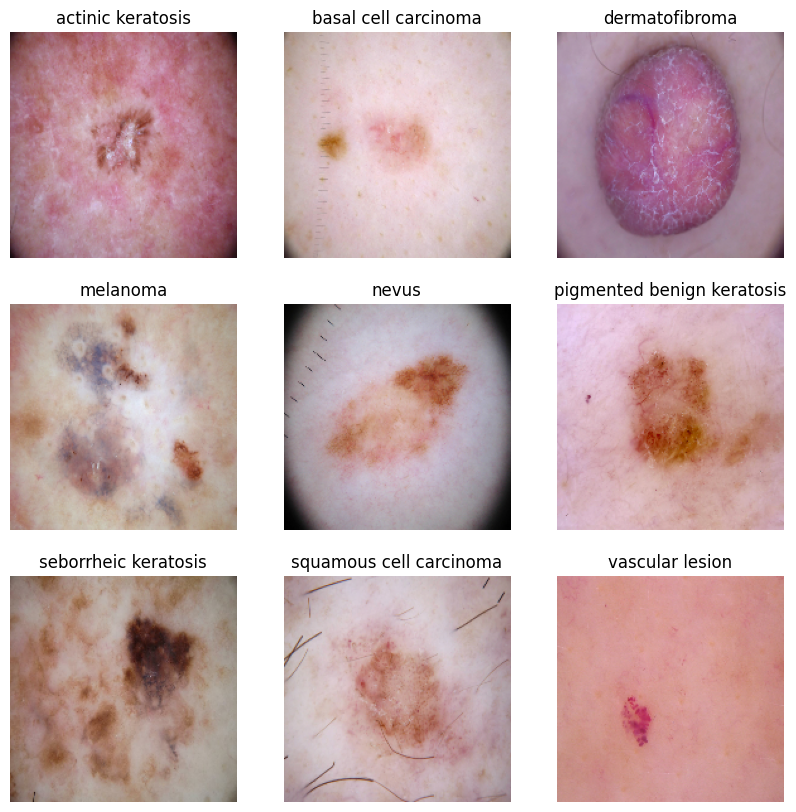

In [183]:
plt.figure(figsize = (10,10))
for i in range(len(class_names)):
    filtered_ds = X_train.filter(lambda x, l: tf.math.equal(l[0], i))
    for image, label in filtered_ds.take(1):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(image[0].numpy().astype('uint8'))
        plt.title(class_names[label.numpy()[0]])
        plt.axis('off')

The image_batch is a tensor of the shape (32, 180, 180, 3). This is a batch of 32 images of shape 180x180x3 (the last dimension refers to color channels RGB). The label_batch is a tensor of the shape (32,), these are corresponding labels to the 32 images.

Dataset.cache() keeps the images in memory after they're loaded off disk during the first epoch.

Dataset.prefetch() overlaps data preprocessing and model execution while training.

In [184]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = X_train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = y_train.cache().prefetch(buffer_size=AUTOTUNE)

In [185]:
# Number of labels are 9
n_labels = 9
input_shape=(img_height, img_width, 3)
inputs = keras.Input(shape=input_shape)

model = Sequential()
model.add(inputs)
model.add(Rescaling(1./255))

model.add(Conv2D(16, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dense(n_labels))
model.add(Activation('relu'))

In [186]:
# summary of the model
print(model.summary())

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_15 (Rescaling)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_64 (Activation)           │ (None, 180, 180, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_65 (Activation)           │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 64800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 128)                 │       8,294,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_66 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 9)                   │           1,161 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_67 (Activation)           │ (None, 9)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,300,777 (31.66 MB)

 Trainable params: 8,300,777 (31.66 MB)

 Non-trainable params: 0 (0.00 B)

None


In [187]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [188]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.1766 - loss: 3.3681 - val_accuracy: 0.1611 - val_loss: 2.1141
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2789 - loss: 1.9591 - val_accuracy: 0.3244 - val_loss: 1.8730
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3388 - loss: 1.8354 - val_accuracy: 0.4944 - val_loss: 1.6880
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4687 - loss: 1.6192 - val_accuracy: 0.3758 - val_loss: 1.8538
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4390 - loss: 1.6467 - val_accuracy: 0.3982 - val_loss: 1.8056
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5292 - loss: 1.4533 - val_accuracy: 0.5145 - val_loss: 1.5799
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5759 - loss: 1.3709 - val_accuracy: 0.5347 - val_loss: 1.5194
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5962 - loss: 1.2788 - val_accuracy: 0.4989 - v

**Visualizing training results**

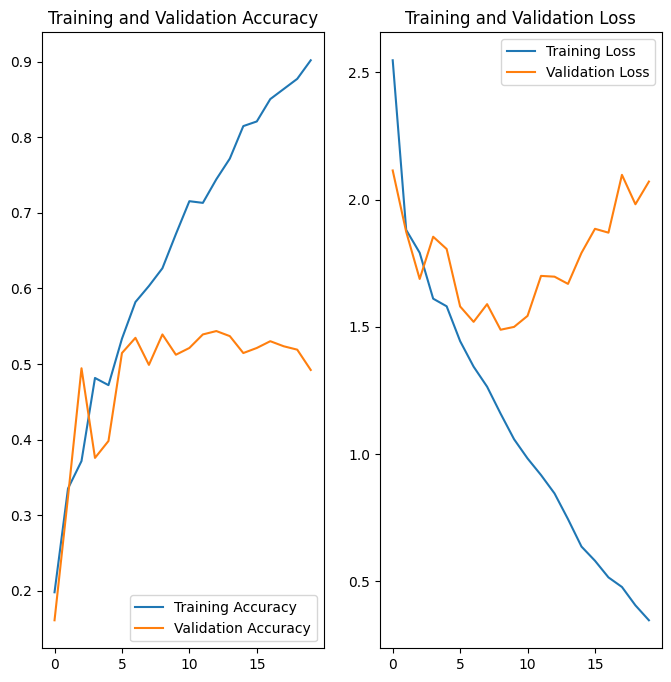

In [189]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Observations**

1. The model's training accuracy is upto 90%, while validation accuracy remains around 49%
2. The drop in the accuracy of the validation dataset shows the case of overfitting. This means the model is having high variance
3. We will next use data augmentation algorithm from Keras to generate more image data and verify the results






In [190]:
# Follow this link to understand and use augmentation using TensorFlow https://www.tensorflow.org/tutorials/images/data_augmentation

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical",
                                                 input_shape=(img_height,
                                                              img_width,
                                                              3)),

  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Visualize how the augmentation strategy works for one instance of training image**

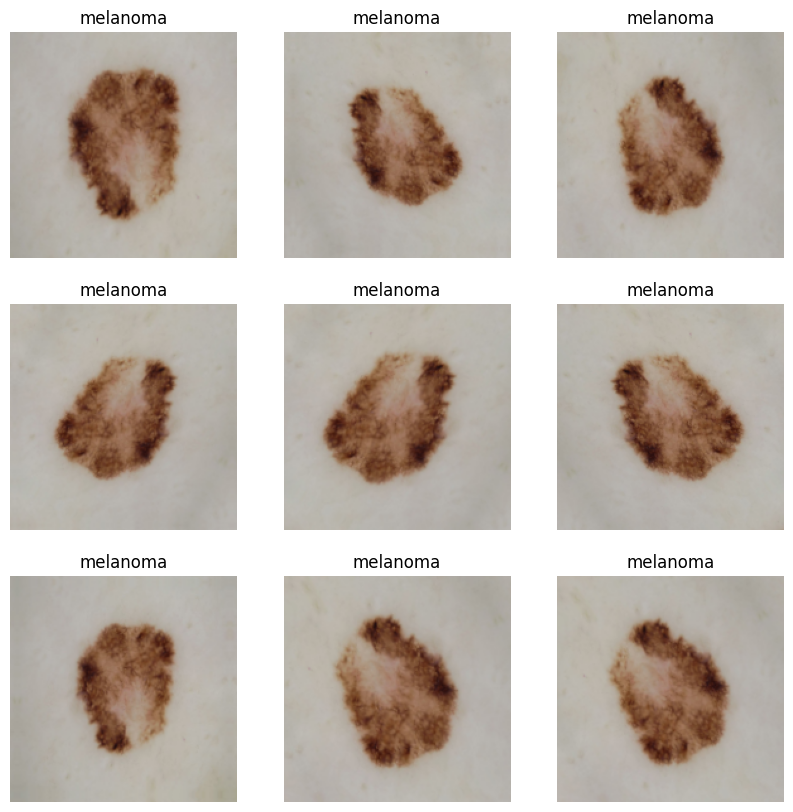

In [191]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.title(class_names[labels[0]])
        plt.axis("off")

**Create the model, compile and train the model**

In [196]:
input_shape=(img_height, img_width, 3)
inputs = keras.Input(shape=input_shape)

model = Sequential()
model.add(inputs)
model.add(Rescaling(1./255))
model.add(data_augmentation)

model.add(Conv2D(16, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dense(n_labels))
model.add(Activation('relu'))

In [197]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [198]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2029 - loss: 3.7002 - val_accuracy: 0.2148 - val_loss: 2.1126
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2738 - loss: 2.0825 - val_accuracy: 0.2953 - val_loss: 2.0328
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3368 - loss: 1.9954 - val_accuracy: 0.1991 - val_loss: 2.0652
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3113 - loss: 2.0016 - val_accuracy: 0.3647 - val_loss: 1.9278
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3484 - loss: 1.9578 - val_accuracy: 0.3535 - val_loss: 1.9346
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3418 - loss: 1.9547 - val_accuracy: 0.3512 - val_loss: 1.9304
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3481 - loss: 1.9045 - val_accuracy: 0.3512 - val_loss: 1.9138
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3316 - loss: 1.9362 - val_accuracy: 0.3691 - v

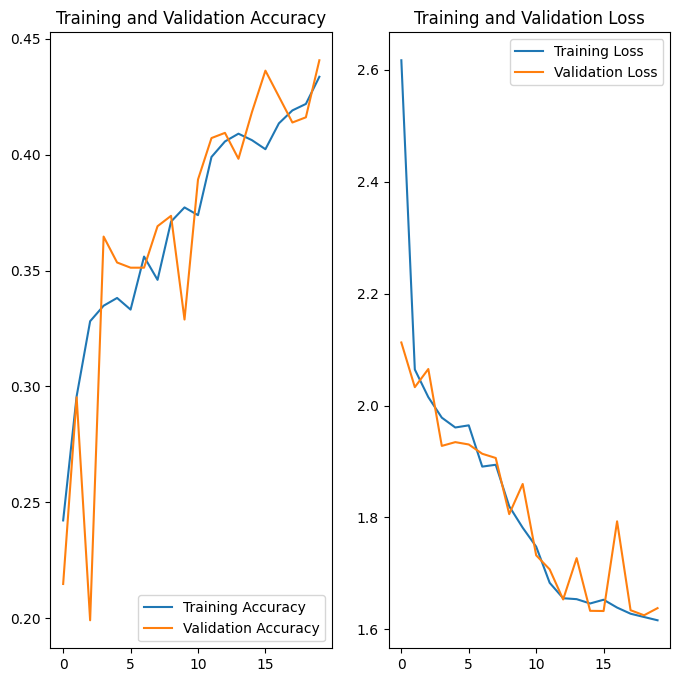

In [199]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Observations**

1. The model's training accuracy is upto 42%, and validation accuracy around 44%
2. Looks like after using data augmentation technique there is not much drop in the validation accuracy as compared to trainning data accuracy. However ,accuracy is within 50% which is not that great
3. We will next verify any class imbalance in the dataset

In [200]:
# A function to get the count of all the files
finalDict = {}
def list_files_walk(start_path='.'):
    count = 0;
    baseFolderName = ''
    parent2 = ''
    finalDict = {}
    for root, dirs, files in os.walk(start_path, topdown=True):
      if count > 0:
          finalDict[baseFolderName] = count;

      count = 0;

      baseFolderName = os.path.basename(root);
      for file in files:
              count = count + 1;

    finalDict[baseFolderName] = count;
    return finalDict;

finalDict = list_files_walk(data_dir_train)

In [201]:
# View the class label and count
skin_disease_label_df = pd.DataFrame([[key,value] for key,value in finalDict.items()],
     columns=["Label","Count"])
skin_disease_label_df[['Count']].astype('int64')
skin_disease_label_df.sort_values(['Count'], ascending=False).head(10)

,Label,Count
5,pigmented benign keratosis,462
1,melanoma,438
3,basal cell carcinoma,376
0,nevus,357
7,squamous cell carcinoma,181
8,vascular lesion,139
4,actinic keratosis,114
2,dermatofibroma,95
6,seborrheic keratosis,77


In [202]:
skin_disease_label_df['Proportion'] = round(skin_disease_label_df[['Count']]/skin_disease_label_df[['Count']].sum() * 100, 2)
skin_disease_label_df.sort_values(['Proportion'], ascending=False)

,Label,Count,Proportion
5,pigmented benign keratosis,462,20.63
1,melanoma,438,19.56
3,basal cell carcinoma,376,16.79
0,nevus,357,15.94
7,squamous cell carcinoma,181,8.08
8,vascular lesion,139,6.21
4,actinic keratosis,114,5.09
2,dermatofibroma,95,4.24
6,seborrheic keratosis,77,3.44


**Class distribution:**

1. Class imbalance is cleary visible from the above table
2. 'seborrheic keratosis' class has the least number of samples
3. 'pigmented benign keratosis' is the dominant of all the classes
4. We will next use Augmentor library to generate images across all the classes to proportionate the number of samples

**Handling class imbalances:**

In [203]:
#import Augmentor
!pip install Augmentor

In [204]:
import Augmentor

for i in class_names:
    p = Augmentor.Pipeline(str(data_dir_train) + '/' + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500)

Initialised with 114 image(s) found.
Output directory set to /content/drive/My Drive/app/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7E7B9871AC50>: 100%|██████████| 500/500 [00:05<00:00, 95.82 Samples/s]


Initialised with 376 image(s) found.
Output directory set to /content/drive/My Drive/app/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7E7B51FE41C0>: 100%|██████████| 500/500 [00:05<00:00, 91.07 Samples/s] 


Initialised with 95 image(s) found.
Output directory set to /content/drive/My Drive/app/Skin cancer ISIC The International Skin Imaging Collaboration/Train/dermatofibroma/output.

...

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x7E7B51D5CBB0>: 100%|██████████| 500/500 [00:09<00:00, 54.23 Samples/s]


Initialised with 181 image(s) found.
Output directory set to /content/drive/My Drive/app/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7E7C55C10AF0>: 100%|██████████| 500/500 [00:05<00:00, 83.83 Samples/s]


Initialised with 139 image(s) found.
Output directory set to /content/drive/My Drive/app/Skin cancer ISIC The International Skin Imaging Collaboration/Train/vascular lesion/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7E7B6B84C910>: 100%|██████████| 500/500 [00:05<00:00, 87.85 Samples/s]


**Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types. Lets take a look at total count of augmented images.**

In [205]:
image_count_train = len(list(data_dir_train.glob('**/*.jpg')))
print(f'Train image count after augmentation = {image_count_train}')

Train image count after augmentation = 6739


**Lets see the distribution of augmented data after adding new images to the original training data.**

In [206]:
path_list = [x for x in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]

In [207]:
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]

In [208]:
dataframe_dict_new = dict(zip(path_list, lesion_list_new))

In [209]:
df2 = pd.DataFrame(list(dataframe_dict_new.items()),columns = ['Path','Label'])

In [210]:
df2['Label'].value_counts()

,count
Label,
nevus,500
melanoma,500
dermatofibroma,500
basal cell carcinoma,500
actinic keratosis,500
pigmented benign keratosis,500
seborrheic keratosis,500
squamous cell carcinoma,500
vascular lesion,500


**Train the model on the data created using Augmentor with Batch Normalization**

In [211]:
(X_train_aug, y_train_aug) = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(img_height, img_width),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='both',
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True
)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.
Using 1347 files for validation.


In [212]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = X_train_aug.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = y_train_aug.cache().prefetch(buffer_size=AUTOTUNE)

In [213]:
input_shape=(img_height, img_width, 3)
inputs = keras.Input(shape=input_shape)

model = Sequential()
model.add(inputs)
model.add(Rescaling(1./255))


model.add(Conv2D(16, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(n_labels))
model.add(Activation('relu'))

In [214]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_10 (Rescaling)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_42 (Activation)           │ (None, 180, 180, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 180, 180, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_43 (Activation)           │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 90, 90, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_44 (Activation)           │ (None, 45, 45, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 45, 45, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_45 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 9)                   │           1,161 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_46 (Activation)           │ (None, 9)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,990,249 (15.22 MB)

 Trainable params: 3,990,025 (15.22 MB)

 Non-trainable params: 224 (896.00 B)

In [215]:
epochs = 30
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - accuracy: 0.0973 - loss: 3.1137 - val_accuracy: 0.0898 - val_loss: 22.9932
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0873 - loss: 2.3039 - val_accuracy: 0.0512 - val_loss: 5.2737
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0902 - loss: 2.2127 - val_accuracy: 0.0898 - val_loss: 2.1972
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0915 - loss: 2.1983 - val_accuracy: 0.0898 - val_loss: 2.1972
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0924 - loss: 2.2040 - val_accuracy: 0.0898 - val_loss: 2.1972
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0946 - loss: 2.1969 - val_accuracy: 0.0898 - val_loss: 2.1972
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0881 - loss: 2.1988 - val_accuracy: 0.0898 - val_loss: 2.1972
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0931 - loss: 2.2022 - val_ac

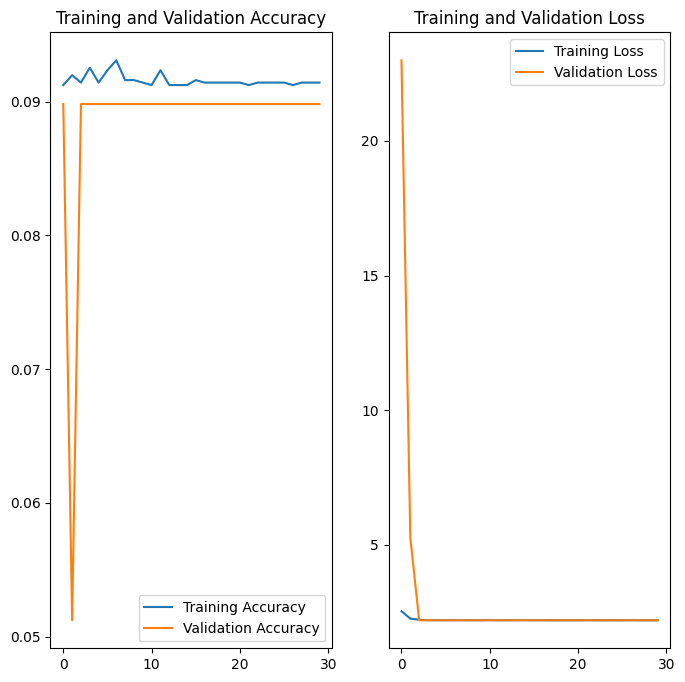

In [216]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Train the model on the data created using Augmentor with Dropout**

In [227]:
input_shape=(img_height, img_width, 3)
inputs = keras.Input(shape=input_shape)

model = Sequential()
model.add(inputs)
model.add(Rescaling(1./255))


model.add(Conv2D(16, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(n_labels))
model.add(Activation('relu'))

In [228]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

In [219]:
model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_19 (Rescaling)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_81 (Activation)           │ (None, 180, 180, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_43 (MaxPooling2D)      │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_44 (Conv2D)                   │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_82 (Activation)           │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_44 (MaxPooling2D)      │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_45 (Conv2D)                   │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_83 (Activation)           │ (None, 45, 45, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_45 (MaxPooling2D)      │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_19 (Flatten)                 │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_84 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 9)                   │           1,161 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_85 (Activation)           │ (None, 9)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,989,801 (15.22 MB)

 Trainable params: 3,989,801 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [229]:
epochs = 30
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.0848 - loss: 2.2684 - val_accuracy: 0.0898 - val_loss: 2.1972
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1037 - loss: 2.1972 - val_accuracy: 0.1403 - val_loss: 2.1929
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1452 - loss: 2.1914 - val_accuracy: 0.2019 - val_loss: 2.1634
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1085 - loss: 2.1900 - val_accuracy: 0.0898 - val_loss: 2.1972
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1063 - loss: 2.1821 - val_accuracy: 0.1292 - val_loss: 2.1760
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2476 - loss: 1.9959 - val_accuracy: 0.2992 - val_loss: 1.8899
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2971 - loss: 1.8477 - val_accuracy: 0.2888 - val_loss: 1.7799
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3721 - loss: 1.6802 - val_acc

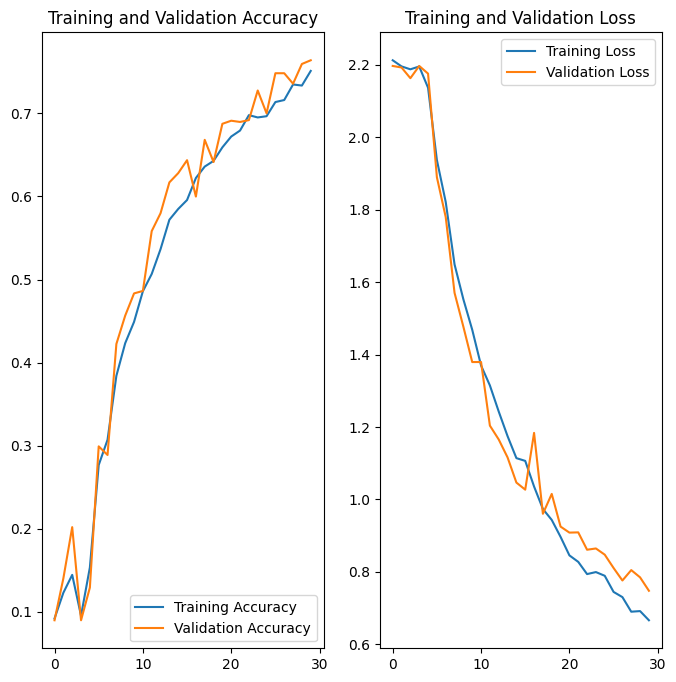

In [230]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Did we get rid of underfitting/overfitting? Did class rebalance help?**

1.   It's cleary visible from the above graph that accuracy has been improved & there is no overfiiting or underfitting of the learning algorithm.
2.   We will next do Prediction on one of the image item



**Predict on data**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Actual Class: nevus
Predicted Class: nevus


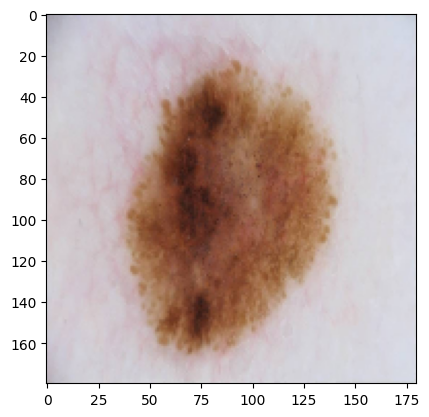

In [231]:
image_path_test = os.path.join(data_dir_test, class_names[4], '*')
test_image = glob(image_path_test)
test_image = load_img(test_image[-1], target_size=input_shape)
plt.imshow(test_image)

img = np.expand_dims(test_image, axis=0)
predicted = model.predict(img)
predicted = np.argmax(predicted)
predicted_class = class_names[predicted]
print('Actual Class: ' + class_names[4] +'\n'+ 'Predicted Class: ' + predicted_class)